## PASO 1: Carga y exploración del JSON

In [61]:
import json5

# Cargar el archivo JSON usando la biblioteca json.
with open("textdetections.json5", "r") as archivo:
    info = json5.load(archivo)

---
## PASO 2: Exploración de la estructura

In [62]:
# Identifica las claves principales: TextDetections y TextModelVersion.
print("Claves principales:")
print(info.keys())


# Observa la organización de los textos en líneas (LINE) y palabras (WORD).
text_detections = info.get("TextDetections", [])

print("\nPrimeras seis filas:")
for deteccion in text_detections[:6]:
    print(deteccion)

Claves principales:
dict_keys(['TextDetections', 'TextModelVersion'])

Primeras seis filas:
{'Confidence': 99.35693359375, 'DetectedText': "IT'S", 'Geometry': {'BoundingBox': {'Height': 0.09988046437501907, 'Left': 0.6684935688972473, 'Top': 0.18226495385169983, 'Width': 0.1461552083492279}, 'Polygon': [{'X': 0.6684935688972473, 'Y': 0.1838926374912262}, {'X': 0.8141663074493408, 'Y': 0.18226495385169983}, {'X': 0.8146487474441528, 'Y': 0.28051772713661194}, {'X': 0.6689760088920593, 'Y': 0.2821454107761383}]}, 'Id': 0, 'Type': 'LINE'}
{'Confidence': 99.6207275390625, 'DetectedText': 'MONDAY', 'Geometry': {'BoundingBox': {'Height': 0.11442459374666214, 'Left': 0.5566731691360474, 'Top': 0.3525116443634033, 'Width': 0.39574965834617615}, 'Polygon': [{'X': 0.5566731691360474, 'Y': 0.353712260723114}, {'X': 0.9522717595100403, 'Y': 0.3525116443634033}, {'X': 0.9524227976799011, 'Y': 0.4657355844974518}, {'X': 0.5568241477012634, 'Y': 0.46693623065948486}]}, 'Id': 1, 'Type': 'LINE'}
{'Conf

---
## PASO 3: Extracción de textos y confidencias

### Recorre la lista TextDetections para obtener:
- El texto detectado (DetectedText).
- El nivel de confianza (Confidence).
- El tipo de elemento (Type: LINE o WORD).

In [63]:
for deteccion in text_detections:
    texto_detectado = deteccion.get("DetectedText")
    confianza = deteccion.get("Confidence")
    tipo_elemento = deteccion.get("Type")

    # Muestra o almacena los textos junto con su nivel de confianza.
    print(f"{tipo_elemento}: '{texto_detectado}' (Confianza: {confianza:.2f}%)")


LINE: 'IT'S' (Confianza: 99.36%)
LINE: 'MONDAY' (Confianza: 99.62%)
LINE: 'but keep' (Confianza: 99.62%)
LINE: 'Smiling' (Confianza: 88.95%)
WORD: 'IT'S' (Confianza: 99.36%)
WORD: 'MONDAY' (Confianza: 99.62%)
WORD: 'but' (Confianza: 99.97%)
WORD: 'keep' (Confianza: 99.26%)
WORD: 'Smiling' (Confianza: 88.95%)


---
## PASO 4: Organización y visualización

In [64]:
from collections import defaultdict

lineas = {}
palabras_linea = defaultdict(list)

# Agrupa las palabras en líneas usando la relación ParentId.
for deteccion in text_detections:
    if deteccion["Type"] == "LINE":
        lineas[deteccion["Id"]] = {
            "text": deteccion["DetectedText"],
            "confidence": deteccion["Confidence"],
            "bounding_box": deteccion["Geometry"]["BoundingBox"],
        }
    elif deteccion["Type"] == "WORD" and "ParentId" in deteccion:
        palabras_linea[deteccion["ParentId"]].append({
            "text": deteccion["DetectedText"],
            "confidence": deteccion["Confidence"],
        })


In [65]:
# Ordena las líneas según su posición vertical (Top de BoundingBox).
lineas_ordenadas = sorted(lineas.items(), key=lambda x: x[1]["bounding_box"]["Top"])

# Muestra las líneas de texto completas en el orden correcto.
print("Texto detectado organizado por líneas:")

i = 0
for id, info_linea in lineas_ordenadas:
    # Comprobar si se trata de una palabra o una línea
    if id in palabras_linea:
        texto = " ".join(palabra["text"] for palabra in palabras_linea[id])
        confianzas = [palabra["confidence"] for palabra in palabras_linea[id]]

    # Calcular la confianza promedio
    confianza_media = sum(confianzas) / len(confianzas)

    i += 1
    print(f"Línea {i}: {texto} (Confianza promedio: {confianza_media:.2f}%)")

Texto detectado organizado por líneas:
Línea 1: IT'S (Confianza promedio: 99.36%)
Línea 2: MONDAY (Confianza promedio: 99.62%)
Línea 3: but keep (Confianza promedio: 99.62%)
Línea 4: Smiling (Confianza promedio: 88.95%)


In [66]:
# Construir el texto completo detectado
texto_completo = ""

for id, info_linea in lineas_ordenadas:
    # Si hay palabras asociadas a la línea se usan y, si no, se usa el texto de la línea
    if id in palabras_linea:
        texto = " ".join([palabra["text"] for palabra in palabras_linea[id]])

    # Añadir la línea al texto completo
    texto_completo += texto + " "

# Eliminar el espacio extra del final
texto_completo = texto_completo.strip()

# Muestra las líneas de texto completas en el orden correcto.
print("\nTexto completo detectado:")
print(texto_completo)



Texto completo detectado:
IT'S MONDAY but keep Smiling


---
## Visualizar posiciones (prueba)

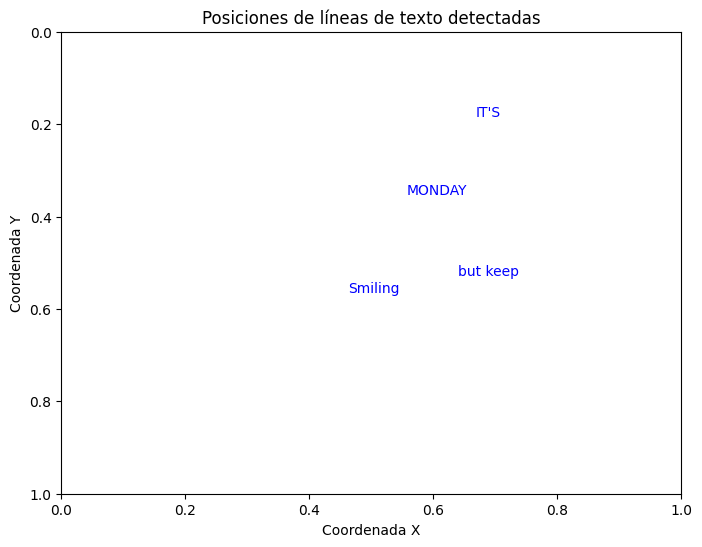

In [67]:
import matplotlib.pyplot as plt

# Visualización de las posiciones
plt.figure(figsize=(8, 6))
for id, info_linea in lineas_ordenadas:
    bbox = info_linea["bounding_box"]
    plt.text(
        bbox["Left"], bbox["Top"],
        lineas[id]["text"],
        fontsize=10, color="blue"
    )

plt.gca().invert_yaxis()  # Invertir el eje Y para alinear con coordenadas de imagen
plt.title("Posiciones de líneas de texto detectadas")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.show()
